## Model training & prediction


#### Data for Modelling

- train_data_fe is the training data for 5 NH_No (feature engineering done)
- test_data_fe is the test data (feature engineering done)

#### Data problems/considerations

- no NH_No column on test data
- we are predicting for same date horizon of training just a new NH_No is selected by organizer

#### Validation: Time-based validation

- need to create validation set: 20% of training_data
- calculate metrics: mae, mape, smape, mis
- output prediction with lower bound and upper bound

#### Models to consider

- try hierarichal models like mixedmodels = mixedLM
- XGBoost with boostrap instead, quantile might be bad CI computation
- Do hyperparameter tuning to get best parameters per dataset. [DONE]
- split data into 3 single-label, different parameters for training per target data [DONE]
- try base data with date engineering only, 10% eval worse [DONE]
- plot feature importance [DONE]
- concatenate NH_No and Group instead into 1 column, test data create dummy base 0 column for this
- split data into dictionary per group then train and forecast


In [8]:
import numpy as np
import random
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

In [9]:
# The training data (train_data_fe.csv) contains the NH_No column (5 NHs per group)
# along with your engineered features and target staffing hour columns.
# The test data (test_data_fe.csv) does not include NH_No and is for a single NH per group.

train_data_fe = pd.read_csv('train_data_base2.csv', parse_dates=['Date'])
test_data_fe = pd.read_csv('test_data_base2.csv', parse_dates=['Date'])


def split_columns_by_target(df):
    """
    Splits DataFrame columns into three groups based on caregiver type.
    
    - Common columns (e.g., Date, Group) are those that do NOT contain 'CNA', 'LPN', or 'RN'
      in their name.
    - For each caregiver type, we take the common columns plus those columns whose names 
      contain the corresponding substring (e.g., "CNA", "LPN", or "RN").
    
    Returns:
        cna_cols, lpn_cols, rn_cols: Lists of column names for each caregiver type.
    """
    # Identify common columns that are not caregiver-specific.
    common_cols = [col for col in df.columns if ('CNA' not in col and 'LPN' not in col and 'RN' not in col)]
    
    # For each target, select columns that contain the substring.
    cna_specific = [col for col in df.columns if 'CNA' in col]
    lpn_specific = [col for col in df.columns if 'LPN' in col]
    rn_specific  = [col for col in df.columns if 'RN' in col]
    
    # Combine common columns with the caregiver-specific ones.
    cna_cols = common_cols + cna_specific
    lpn_cols = common_cols + lpn_specific
    rn_cols  = common_cols + rn_specific
    
    # Remove duplicates (if any) while preserving order.
    cna_cols = list(dict.fromkeys(cna_cols))
    lpn_cols = list(dict.fromkeys(lpn_cols))
    rn_cols  = list(dict.fromkeys(rn_cols))
    
    return cna_cols, lpn_cols, rn_cols


# change train_data to train_data_model in function header
def data_modelling(train_data_model, test_data, target_col):
    # Assume the target columns are the staffing hours: 'Hrs_CNA', 'Hrs_LPN', and 'Hrs_RN'.
    target_cols = target_col

    # # Remove the identifier column from the training data (if present)
    # if 'NH_No' in train_data.columns:
    #     train_data_model = train_data.drop(columns=['NH_No'])
    # else:
    #     train_data_model = train_data.copy()

    # Convert the Date column to ordinal (numeric) - object cannot
    train_data_model['Date'] = pd.to_datetime(train_data_model['Date'], errors='coerce')
    test_data['Date'] = pd.to_datetime(test_data['Date'], errors='coerce')

    # Define feature columns as those not in target_cols.
    feature_cols = [col for col in train_data_model.columns if col not in target_cols]

    # Sort the training data by the Date column.
    train_data_model_sorted = train_data_model.sort_values(by='Date')

    # Specify the split date
    split_date = pd.Timestamp('2024-06-12')

    # Create the training set (data before the split date) and validation set (data on/after the split date)
    train_data_final = train_data_model_sorted[train_data_model_sorted['Date'] < split_date]
    val_data_final = train_data_model_sorted[train_data_model_sorted['Date'] >= split_date]

    # Convert date to numerical
    train_data_final['Date'] = train_data_final['Date'].apply(lambda x: x.toordinal())
    val_data_final['Date'] = val_data_final['Date'].apply(lambda x: x.toordinal())
    test_data['Date'] = test_data['Date'].apply(lambda x: x.toordinal())

    # Extract features and targets for training and validation.
    X_train = train_data_final[feature_cols]
    y_train = train_data_final[target_cols]
    X_val = val_data_final[feature_cols]
    y_val = val_data_final[target_cols]

    return X_train, y_train, X_val, y_val

In [10]:
def get_minimum_staffing(caregiver_type):
    """
    Return minimum realistic staffing hours based on caregiver type
    """
    if caregiver_type == 'CNA':
        return 80.0  # CNAs typically have higher staffing hours
    elif caregiver_type == 'LPN':
        return 40.0  # LPNs have moderate staffing hours
    elif caregiver_type == 'RN':
        return 15.0  # RNs might have fewer hours
    else:
        return 5.0   # Default minimum

In [11]:
# shud be train_data and test_data not +_fe
# Split columns for train and test data
train_cna_cols, train_lpn_cols, train_rn_cols = split_columns_by_target(train_data_fe)
test_cna_cols, test_lpn_cols, test_rn_cols    = split_columns_by_target(test_data_fe)

# Create separate DataFrames for each caregiver type.
train_cna = train_data_fe[train_cna_cols]
train_lpn = train_data_fe[train_lpn_cols]
train_rn  = train_data_fe[train_rn_cols]

test_cna = test_data_fe[test_cna_cols]
test_lpn = test_data_fe[test_lpn_cols]
test_rn  = test_data_fe[test_rn_cols]

# For CNA:
X_train_cna, y_train_cna, X_val_cna, y_val_cna = data_modelling(train_cna, test_cna, 'CNA')
# For LPN:
X_train_lpn, y_train_lpn, X_val_lpn, y_val_lpn = data_modelling(train_lpn, test_lpn, 'LPN')
# For RN:
X_train_rn,  y_train_rn,  X_val_rn,  y_val_rn  = data_modelling(train_rn, test_rn,  'RN')

# (Optional) Print shapes to verify the splits
print("CNA Train/Val shapes:", X_train_cna.shape, X_val_cna.shape)
print("LPN Train/Val shapes:", X_train_lpn.shape, X_val_lpn.shape)
print("RN Train/Val shapes: ", X_train_rn.shape,  X_val_rn.shape)

CNA Train/Val shapes: (7200, 14) (1900, 14)
LPN Train/Val shapes: (7200, 14) (1900, 14)
RN Train/Val shapes:  (7200, 14) (1900, 14)


In [12]:
# Define Custom Quantile Loss Functions for XGBoost for CI
# Fix 1: Better quantile loss implementation
def quantile_loss_obj(preds, dtrain, quantile):
    """
    Objective function for quantile regression
    
    For quantile q, the loss is:
    q * (y - pred) if y > pred (underestimation)
    (1-q) * (pred - y) if y <= pred (overestimation)
    """
    labels = dtrain.get_label()
    errors = labels - preds
    
    # Different gradients for under vs over estimation
    grad = np.where(errors >= 0, -quantile, (1 - quantile))
    
    # Use a small constant for hessian to stabilize training
    # Lower quantiles need more stability
    if quantile < 0.3:
        hess = np.ones_like(labels) * 0.2
    else:
        hess = np.ones_like(labels) * 0.1
        
    return grad, hess

def quantile_loss_eval(preds, dtrain, quantile):
    """
    Evaluation metric for quantile regression
    """
    labels = dtrain.get_label()
    errors = labels - preds
    
    # The pinball/quantile loss
    loss = np.where(errors >= 0, quantile * errors, (quantile - 1) * errors)
    
    return 'quantile_loss', np.mean(loss)


# Fix 2: Better parameters for extreme quantiles
def get_quantile_params(base_params, quantile):
    """
    Adjust XGBoost parameters based on quantile level
    """
    # Clone the base parameters
    params = base_params.copy()
    
    # No change for median
    if quantile == 0.5:
        return params
    
    # Different parameter adjustments for lower and upper quantiles
    if quantile < 0.5:  # Lower bound
        # More conservative for lower bound to avoid unrealistically low predictions
        extremity = abs(quantile - 0.5)
        factor = 1 + extremity * 3  # More aggressive regularization for lower bound
        
        # Increase regularization to prevent extreme predictions
        params['lambda'] = params.get('lambda', 1.0) * factor
        params['alpha'] = params.get('alpha', 0.0) * factor
        params['gamma'] = params.get('gamma', 0.0) + extremity  # Increase pruning threshold
        
        # Reduce learning rate more for lower quantile
        params['eta'] = params.get('eta', 0.05) / (factor * 1.2)
        
        # Add constraints to avoid overfitting to extreme values
        params['min_child_weight'] = max(params.get('min_child_weight', 1), 5)
    else:  # Upper bound
        # Standard adjustment for upper bound
        extremity = abs(quantile - 0.5)
        factor = 1 + extremity * 2
        
        # Standard regularization adjustments
        params['lambda'] = params.get('lambda', 1.0) * factor
        params['alpha'] = params.get('alpha', 0.0) * factor
        
        # Reduce learning rate
        params['eta'] = params.get('eta', 0.05) / factor
    
    return params

In [13]:
# Metrics
def mae(y_true, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    """Mean Absolute Percentage Error with a threshold to avoid division by small numbers"""
    threshold = 1.0  # Use a threshold of 1.0 (adjust as needed)
    mask = y_true > threshold
    if not np.any(mask):
        return np.nan
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    return 100 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

# Fix 4: Better MIS implementation to match training objective
def mis(y_true, lower, upper, alpha=0.05):
    """
    Mean Interval Score (MIS)
    Smaller values are better.
    """
    width = upper - lower
    under_penalty = (2/alpha) * np.maximum(0, lower - y_true)
    over_penalty = (2/alpha) * np.maximum(0, y_true - upper)
    total_penalty = width + under_penalty + over_penalty
    return np.mean(total_penalty)  # Using mean instead of median for consistency

In [14]:
# Hyperparameter tuning
def tune_hyperparameters_with_ci(X_train, y_train, target_name, n_trials=50):
    print(f"\n--- Starting Hyperparameter Tuning for {target_name} ---")
    
    # Create TimeSeriesSplit with more folds
    tscv = TimeSeriesSplit(n_splits=5)
    
    def objective(trial):
        # Define parameter search space with more focused ranges
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'eta': trial.suggest_float('eta', 0.01, 0.2, log=True),  # Expanded upper bound
            # 'subsample': trial.suggest_float('subsample', 0.7, 0.9),  # More conservative subsampling
            'subsample': 0.8,  # More conservative subsampling
            # 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.9),
            'colsample_bytree': 0.75,
            'lambda': trial.suggest_float('lambda', 0.5, 5.0),  # Increased lower bound
            'alpha': trial.suggest_float('alpha', 0.5, 5.0),  # Increased lower bound
            'gamma': trial.suggest_float('gamma', 0.1, 2.0),  # Narrower range
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 7),  # Increased lower bound
            'verbosity': 0
        }
        
        # Initialize metrics for cross-validation
        cv_mae_scores = []
        cv_ci_scores = []
        cv_coverage_scores = []  # New metric for interval coverage
        
        # Perform time series cross-validation
        for train_idx, val_idx in tscv.split(X_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            # Train models for each quantile
            models = {}
            for q in [0.025, 0.5, 0.975]:
                q_params = get_quantile_params(params, q)
                dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train)
                
                def obj(preds, dtrain):
                    return quantile_loss_obj(preds, dtrain, q)
                
                def feval(preds, dtrain):
                    return quantile_loss_eval(preds, dtrain, q)
                
                # Train with early stopping
                dval = xgb.DMatrix(X_fold_val, label=y_fold_val)
                model = xgb.train(
                    q_params,
                    dtrain,
                    num_boost_round=100,
                    obj=obj,
                    feval=feval,
                    evals=[(dval, 'val')],
                    early_stopping_rounds=10,
                    verbose_eval=False
                )
                
                models[q] = model
            
            # Predict on validation set
            dval = xgb.DMatrix(X_fold_val)
            median_preds = models[0.5].predict(dval)
            lower_preds = models[0.025].predict(dval)
            upper_preds = models[0.975].predict(dval)
            
            # Calculate metrics
            fold_mae = mae(y_fold_val, median_preds)
            fold_mis = mis(y_fold_val, lower_preds, upper_preds, alpha=0.05)
            
            # Calculate interval coverage
            fold_coverage = np.mean((y_fold_val >= lower_preds) & (y_fold_val <= upper_preds))
            coverage_penalty = abs(fold_coverage - 0.95) * 10
            
            # Combined CI quality score with coverage penalty
            fold_ci_score = fold_mis + coverage_penalty
            
            cv_mae_scores.append(fold_mae)
            cv_ci_scores.append(fold_ci_score)
            cv_coverage_scores.append(fold_coverage)
        
        # More balanced objective function
        avg_mae = np.mean(cv_mae_scores)
        avg_ci_score = np.mean(cv_ci_scores)
        avg_coverage = np.mean(cv_coverage_scores)
        
        if trial.number % 5 == 0:
            print(f"Trial {trial.number}: MAE = {avg_mae:.4f}, CI Score = {avg_ci_score:.4f}, Coverage = {avg_coverage:.4f}")
        
        # Balance MAE and CI quality
        return avg_mae * 0.5 + avg_ci_score * 0.5
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"\nBest {target_name} Parameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    
    return study.best_params

# Run for CNA, LPN, RN
best_params_cna = tune_hyperparameters_with_ci(X_train_cna, y_train_cna, 'CNA')
best_params_lpn = tune_hyperparameters_with_ci(X_train_lpn, y_train_lpn, 'LPN')
best_params_rn = tune_hyperparameters_with_ci(X_train_rn, y_train_rn, 'RN')

print("\nBest CNA Params:", best_params_cna)
print("\nBest LPN Params:", best_params_lpn)
print("\nBest RN Params:", best_params_rn)

[I 2025-02-28 15:54:00,882] A new study created in memory with name: no-name-e95e6f2b-82a2-4db9-b033-8022ce3e0540



--- Starting Hyperparameter Tuning for CNA ---


[I 2025-02-28 15:54:07,466] Trial 0 finished with value: 3022.938631823327 and parameters: {'max_depth': 3, 'eta': 0.016869065534425052, 'lambda': 3.5981280110290017, 'alpha': 1.3277211875084725, 'gamma': 1.1927981427279328, 'min_child_weight': 3}. Best is trial 0 with value: 3022.938631823327.


Trial 0: MAE = 146.9214, CI Score = 5898.9558, Coverage = 0.0023


[I 2025-02-28 15:54:13,774] Trial 1 finished with value: 2705.712471298286 and parameters: {'max_depth': 4, 'eta': 0.050641727357188984, 'lambda': 4.564526650702414, 'alpha': 2.8433785722888154, 'gamma': 0.3569001738562473, 'min_child_weight': 6}. Best is trial 1 with value: 2705.712471298286.
[I 2025-02-28 15:54:19,981] Trial 2 finished with value: 2134.8409188976843 and parameters: {'max_depth': 4, 'eta': 0.1131434236001698, 'lambda': 3.6622858606178124, 'alpha': 4.2593391594521055, 'gamma': 1.4934958816097634, 'min_child_weight': 5}. Best is trial 2 with value: 2134.8409188976843.
[I 2025-02-28 15:54:25,670] Trial 3 finished with value: 2798.9737084512167 and parameters: {'max_depth': 3, 'eta': 0.03930254646813341, 'lambda': 0.5061115056736734, 'alpha': 3.9849729173073407, 'gamma': 1.7158523245296289, 'min_child_weight': 4}. Best is trial 2 with value: 2134.8409188976843.
[I 2025-02-28 15:54:31,729] Trial 4 finished with value: 1923.6998900444603 and parameters: {'max_depth': 3, 'et

...

Trial 40: MAE = 21.6349, CI Score = 845.9774, Coverage = 0.2230


[I 2025-02-28 16:08:19,564] Trial 41 finished with value: 92.68348972663604 and parameters: {'max_depth': 5, 'eta': 0.1714173508107629, 'lambda': 2.107111904282442, 'alpha': 3.26361520360524, 'gamma': 0.4659841674101066, 'min_child_weight': 5}. Best is trial 38 with value: 69.10036923630517.
[I 2025-02-28 16:08:24,457] Trial 42 finished with value: 71.62577018816395 and parameters: {'max_depth': 6, 'eta': 0.19332976581366948, 'lambda': 0.9514096486003784, 'alpha': 2.7750935095277685, 'gamma': 0.35767890730418556, 'min_child_weight': 6}. Best is trial 38 with value: 69.10036923630517.
[I 2025-02-28 16:08:29,293] Trial 43 finished with value: 117.26446485085775 and parameters: {'max_depth': 5, 'eta': 0.13553092755088816, 'lambda': 0.5534984753263703, 'alpha': 2.643845894790759, 'gamma': 0.3644542610085694, 'min_child_weight': 5}. Best is trial 38 with value: 69.10036923630517.
[I 2025-02-28 16:08:34,053] Trial 44 finished with value: 162.90124845098163 and parameters: {'max_depth': 6, 'e

Trial 45: MAE = 8.5386, CI Score = 172.4214, Coverage = 0.7653


[I 2025-02-28 16:08:43,836] Trial 46 finished with value: 131.86326387922998 and parameters: {'max_depth': 6, 'eta': 0.12400655112738448, 'lambda': 0.5036619263621118, 'alpha': 1.8400092362265825, 'gamma': 0.10195068461369118, 'min_child_weight': 3}. Best is trial 38 with value: 69.10036923630517.
[I 2025-02-28 16:08:48,177] Trial 47 finished with value: 551.3100036339562 and parameters: {'max_depth': 6, 'eta': 0.01967393587126324, 'lambda': 4.820977586817705, 'alpha': 3.288525680131301, 'gamma': 1.5549253992234373, 'min_child_weight': 4}. Best is trial 38 with value: 69.10036923630517.
[I 2025-02-28 16:08:53,193] Trial 48 finished with value: 67.22979849457934 and parameters: {'max_depth': 7, 'eta': 0.19819529958189844, 'lambda': 0.7370116941336147, 'alpha': 2.5624881043143315, 'gamma': 0.6853193504490593, 'min_child_weight': 6}. Best is trial 48 with value: 67.22979849457934.
[I 2025-02-28 16:08:57,693] Trial 49 finished with value: 603.0091906641579 and parameters: {'max_depth': 7, 


Best RN Parameters:
  max_depth: 7
  eta: 0.19819529958189844
  lambda: 0.7370116941336147
  alpha: 2.5624881043143315
  gamma: 0.6853193504490593
  min_child_weight: 6

Best CNA Params: {'max_depth': 4, 'eta': 0.19987230287065386, 'lambda': 1.0301988274876845, 'alpha': 2.426449358955596, 'gamma': 0.2162416038337302, 'min_child_weight': 7}

Best LPN Params: {'max_depth': 3, 'eta': 0.19818383862856648, 'lambda': 2.8670717371127403, 'alpha': 1.2151171546489514, 'gamma': 0.7195856020715597, 'min_child_weight': 6}

Best RN Params: {'max_depth': 7, 'eta': 0.19819529958189844, 'lambda': 0.7370116941336147, 'alpha': 2.5624881043143315, 'gamma': 0.6853193504490593, 'min_child_weight': 6}


In [57]:
# Set Up the Modeling Strategy: Quantile Regression with XGBoost
# We choose three quantiles: 0.025 (lower bound), 0.5 (point/median prediction), and 0.975 (upper bound).
quantiles = [0.025, 0.5, 0.975]

# Define basic XGBoost parameters (you can further tune these per caregiver type)

# params_cna= {'max_depth': 4, 'eta': 0.19992107348380397, 'subsample': 0.8889408647614726, 'colsample_bytree': 0.8387598852442392, 'lambda': 1.0491841256449936, 'alpha': 3.7730329015706707, 'gamma': 1.2080452971656217, 'min_child_weight': 3}
# params_lpn={'max_depth': 5, 'eta': 0.19534683611618336, 'subsample': 0.8768163453592064, 'colsample_bytree': 0.7065927204038771, 'lambda': 0.9713184610906044, 'alpha': 3.6566453941270405, 'gamma': 0.1916939827471813, 'min_child_weight': 6}
params_rn={'max_depth': 3, 'eta': 0.18652841904204343, 'subsample': 0.8130185137217261, 'colsample_bytree': 0.812885920866895, 'lambda': 2.2053464444668838, 'alpha': 0.5545863265111528, 'gamma': 1.9696384475712334, 'min_child_weight': 6}

params_cna= {'max_depth': 4, 'eta': 0.19992107348380397, 'subsample': 0.8889408647614726, 'colsample_bytree': 0.8387598852442392, 'lambda': 1.0491841256449936, 'alpha': 2.426449358955596, 'gamma': 0.2162416038337302, 'min_child_weight': 7}

params_lpn={'max_depth': 3, 'eta': 0.19534683611618336, 'subsample': 0.8768163453592064, 'colsample_bytree': 0.7065927204038771, 'lambda': 0.9713184610906044, 'alpha': 3.6566453941270405, 'gamma': 0.1916939827471813, 'min_child_weight': 6}

# params_rn={'max_depth': 7, 'eta': 0.18652841904204343, 'subsample': 0.8130185137217261, 'colsample_bytree': 0.812885920866895, 'lambda': 0.7370116941336147, 'alpha': 2.5624881043143315, 'gamma': 0.6853193504490593, 'min_child_weight': 6}


# Fix 3: Make sure models are properly evaluated and selected
def train_quantile_model(X, y, quantile, base_params, num_round):
    dtrain = xgb.DMatrix(X, label=y)
    
    # Get adjusted parameters for this quantile
    params = get_quantile_params(base_params, quantile)
    
    # Define callbacks for early stopping
    callbacks = [
        xgb.callback.EarlyStopping(
            rounds=50,
            metric_name='quantile_loss',
            min_delta=0.001,
            save_best=True
        )
    ]

        
    def obj(preds, dtrain):
        return quantile_loss_obj(preds, dtrain, quantile)
    
    def feval(preds, dtrain):
        return quantile_loss_eval(preds, dtrain, quantile)
        
    model = xgb.train(
        params, 
        dtrain, 
        num_round, 
        obj=obj, 
        feval=feval,
        callbacks=callbacks
    )
    
    return model

# Fix 7: Cross-validation for better model stability
def train_models_for_target(X_train, y_train, quantiles, params, num_round):
    models = {}
    
    # Create 5-fold time series cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    for q in quantiles:
        fold_models = []
        fold_scores = []
        
        for train_idx, val_idx in tscv.split(X_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            # Train model on this fold
            dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train)
            dval = xgb.DMatrix(X_fold_val, label=y_fold_val)
            
            # Get quantile-specific parameters
            custom_params = get_quantile_params(params, q)
            
            def obj(preds, dtrain):
                return quantile_loss_obj(preds, dtrain, q)
            
            def feval(preds, dtrain):
                return quantile_loss_eval(preds, dtrain, q)
            
            # Train with early stopping and validation
            model = xgb.train(
                custom_params, 
                dtrain, 
                num_round, 
                obj=obj, 
                feval=feval,
                evals=[(dval, 'val')],
                early_stopping_rounds=50,
                verbose_eval=False
            )
            
            # Evaluate the model
            preds = model.predict(dval)
            if q == 0.5:
                # For median model, use MAE
                score = mae(y_fold_val, preds)
            else:
                # For boundary models, use quantile loss
                errors = y_fold_val - preds
                if q < 0.5:
                    # Lower bound - penalize underestimation
                    score = np.mean(np.where(errors < 0, q * errors, (q - 1) * errors))
                else:
                    # Upper bound - penalize overestimation
                    score = np.mean(np.where(errors > 0, q * errors, (q - 1) * errors))
            
            fold_models.append(model)
            fold_scores.append(score)
        
        # Select the best model for this quantile
        best_model_idx = np.argmin(fold_scores)
        models[q] = fold_models[best_model_idx]
        print(f"Quantile {q}: Selected fold {best_model_idx+1} with score {fold_scores[best_model_idx]:.4f}")
    
    return models

# Train separate models for each target.
num_round = 500
models_cna = train_models_for_target(X_train_cna, y_train_cna, quantiles, params_cna, num_round)
models_lpn = train_models_for_target(X_train_lpn, y_train_lpn, quantiles, params_lpn, num_round)
models_rn  = train_models_for_target(X_train_rn,  y_train_rn,  quantiles, params_rn, num_round)

Quantile 0.025: Selected fold 3 with score -148.1240
Quantile 0.5: Selected fold 4 with score 9.2515
Quantile 0.975: Selected fold 4 with score 1.3520
Quantile 0.025: Selected fold 1 with score -51.2791
Quantile 0.5: Selected fold 4 with score 7.2155
Quantile 0.975: Selected fold 4 with score 0.5233
Quantile 0.025: Selected fold 1 with score -32.4138
Quantile 0.5: Selected fold 4 with score 6.3403
Quantile 0.975: Selected fold 4 with score 0.4703


In [58]:
# def enforce_quantile_monotonicity(predictions, caregiver_type):
#     """
#     Ensure quantile predictions respect domain constraints and monotonicity
#     """
#     # Create a new dictionary to store the results
#     result = {}
    
#     # Check if inputs are Series and if so, get values and remember indices
#     series_index = None
#     if isinstance(predictions['point'], pd.Series):
#         series_index = predictions['point'].index
#         for key in predictions:
#             result[key] = predictions[key].values.copy()
#     else:
#         for key in predictions:
#             result[key] = predictions[key].copy()
    
#     # Get minimum allowable value for this caregiver type
#     min_value = get_minimum_staffing(caregiver_type)
    
#     # Apply floor values to all predictions
#     result['lower'] = np.maximum(result['lower'], min_value)
#     result['point'] = np.maximum(result['point'], min_value)
#     result['upper'] = np.maximum(result['upper'], min_value)
    
#     # Define maximum allowed deviation from point prediction (as percentage)
#     max_deviations = {
#         'CNA': {'lower': 0.25, 'upper': 0.30},  # CNA: lower bound at most 25% below median
#         'LPN': {'lower': 0.30, 'upper': 0.35},  # LPN: lower bound at most 30% below median
#         'RN': {'lower': 0.35, 'upper': 0.40}    # RN: lower bound at most 35% below median
#     }
    
#     # Get deviation limits for this caregiver type
#     max_lower_dev = max_deviations.get(caregiver_type, {'lower': 0.30, 'upper': 0.35})['lower']
#     max_upper_dev = max_deviations.get(caregiver_type, {'lower': 0.30, 'upper': 0.35})['upper']
    
#     # Calculate minimum allowed lower bound (as percentage of point estimate)
#     min_lower = result['point'] * (1 - max_lower_dev)
#     min_lower = np.maximum(min_lower, min_value)  # Re-apply absolute floor
    
#     # Calculate maximum allowed upper bound (as percentage of point estimate)
#     max_upper = result['point'] * (1 + max_upper_dev)
    
#     # Apply constraints
#     result['lower'] = np.maximum(result['lower'], min_lower)
#     result['upper'] = np.minimum(result['upper'], max_upper)
    
#     # Apply light smoothing to reduce volatility in CI bounds
#     window_size = 3  # Small window to preserve general patterns
    
#     # Only apply smoothing if we have enough data points
#     if len(result['lower']) > 2:
#         # Convert to pandas Series for rolling operations
#         lower_series = pd.Series(result['lower'])
#         upper_series = pd.Series(result['upper'])
        
#         # Apply smoothing
#         result['lower'] = lower_series.rolling(window=window_size, min_periods=1, center=True).mean().values
#         result['upper'] = upper_series.rolling(window=window_size, min_periods=1, center=True).mean().values
    
#     # Final monotonicity check
#     result['lower'] = np.minimum(result['lower'], result['point'])
#     result['upper'] = np.maximum(result['upper'], result['point'])
    
#     # Convert back to Series if the input was Series
#     if series_index is not None:
#         for key in result:
#             result[key] = pd.Series(result[key], index=series_index)
    
#     return result

In [59]:
def enforce_quantile_monotonicity(predictions, caregiver_type):
    """
    Ensure quantile predictions respect monotonicity without minimum value capping
    """
    # Create a new dictionary to store the results
    result = {}
    
    # Check if inputs are Series and if so, get values and remember indices
    series_index = None
    if isinstance(predictions['point'], pd.Series):
        series_index = predictions['point'].index
        for key in predictions:
            result[key] = predictions[key].values.copy()
    else:
        for key in predictions:
            result[key] = predictions[key].copy()
    
    # Remove negative values only (physical constraint)
    result['lower'] = np.maximum(result['lower'], 0.0)
    result['point'] = np.maximum(result['point'], 0.0)
    result['upper'] = np.maximum(result['upper'], 0.0)
    
    # Define maximum allowed deviation from point prediction (as percentage)
    # max_deviations = {
    #     'CNA': {'lower': 0.25, 'upper': 0.30},
    #     'LPN': {'lower': 0.30, 'upper': 0.35},
    #     'RN': {'lower': 0.35, 'upper': 0.40}
    # }
    
    max_deviations = {
    'CNA': {'lower': 0.50, 'upper': 0.60},  # Doubled from previous values
    'LPN': {'lower': 0.60, 'upper': 0.70},  # Doubled from previous values
    'RN': {'lower': 0.70, 'upper': 0.80}    # Doubled from previous values
}
    
#     max_deviations = {
#     'CNA': {'lower': 0.15, 'upper': 0.20},  # Doubled from previous values
#     'LPN': {'lower': 0.25, 'upper': 0.30},  # Doubled from previous values
#     'RN': {'lower': 0.30, 'upper': 0.35}    # Doubled from previous values
# }

    # Get deviation limits for this caregiver type
    max_lower_dev = max_deviations.get(caregiver_type, {'lower': 0.30, 'upper': 0.35})['lower']
    max_upper_dev = max_deviations.get(caregiver_type, {'lower': 0.30, 'upper': 0.35})['upper']
    
    # Calculate bounds based on percentage (but don't enforce minimum value)
    min_lower = result['point'] * (1 - max_lower_dev)
    max_upper = result['point'] * (1 + max_upper_dev)
    
    # Apply constraints
    result['lower'] = np.maximum(result['lower'], min_lower)
    result['upper'] = np.minimum(result['upper'], max_upper)
    
    # Apply light smoothing to reduce volatility in CI bounds
    window_size = 3  # Small window to preserve general patterns
    
    # Only apply smoothing if we have enough data points
    if len(result['lower']) > 2:
        # Convert to pandas Series for rolling operations
        lower_series = pd.Series(result['lower'])
        upper_series = pd.Series(result['upper'])
        
        # Apply smoothing
        result['lower'] = lower_series.rolling(window=window_size, min_periods=1, center=True).mean().values
        result['upper'] = upper_series.rolling(window=window_size, min_periods=1, center=True).mean().values
    
    # Final monotonicity check
    result['lower'] = np.minimum(result['lower'], result['point'])
    result['upper'] = np.maximum(result['upper'], result['point'])
    
    # Convert back to Series if the input was Series
    if series_index is not None:
        for key in result:
            result[key] = pd.Series(result[key], index=series_index)
    
    return result

In [60]:
# Model Evaluation
# Define a helper function to get predictions for a single target.
def get_predictions_for_target(models, X):
    """
    Given a dictionary of quantile models for one target (keys are quantiles),
    return a dictionary of predictions for each quantile.
    """
    preds = {}
    dmatrix = xgb.DMatrix(X)
    for q in quantiles:
        preds[q] = models[q].predict(dmatrix)
    return preds

def evaluate_prediction_intervals(y_true, y_pred, lower, upper, alpha=0.05):
    """
    Evaluate the quality of prediction intervals
    """
    # Convert to numpy arrays if they're pandas Series
    if isinstance(y_true, pd.Series):
        y_true = y_true.values
    if isinstance(y_pred, pd.Series):
        y_pred = y_pred.values
    if isinstance(lower, pd.Series):
        lower = lower.values
    if isinstance(upper, pd.Series):
        upper = upper.values
    
    # Calculate coverage (percentage of true values within interval)
    coverage = np.mean((y_true >= lower) & (y_true <= upper))
    
    # Calculate interval width
    width = np.mean(upper - lower)
    
    # Calculate MIS
    mis_value = mis(y_true, lower, upper, alpha)
    
    # Calculate point prediction metrics
    mae_value = mae(y_true, y_pred)
    
    try:
        mape_value = mape(y_true, y_pred)
    except:
        mape_value = np.nan
    
    smape_value = smape(y_true, y_pred)
    
    return {
        'coverage': coverage,
        'target_coverage': 1 - alpha,
        'coverage_error': abs(coverage - (1 - alpha)),
        'width': width,
        'mis': mis_value,
        'mae': mae_value,
        'mape': mape_value,
        'smape': smape_value
    }

def evaluate_target(models, X_train, X_val, y_train, y_val, target):
    """
    Evaluate models with improved metrics focusing on CI quality
    """
    # Obtain predictions for training and validation sets
    train_preds = get_predictions_for_target(models, X_train)
    val_preds = get_predictions_for_target(models, X_val)
    
    # Apply domain constraints to training predictions
    train_point = train_preds[0.5]
    train_lower = train_preds[0.025]
    train_upper = train_preds[0.975]
    
    train_constrained = enforce_quantile_monotonicity({
        'point': train_point,
        'lower': train_lower,
        'upper': train_upper
    }, caregiver_type=target)
    
    train_point = train_constrained['point']
    train_lower = train_constrained['lower']
    train_upper = train_constrained['upper']
    
    # Apply domain constraints to validation predictions
    val_point = val_preds[0.5]
    val_lower = val_preds[0.025]
    val_upper = val_preds[0.975]
    
    val_constrained = enforce_quantile_monotonicity({
        'point': val_point,
        'lower': val_lower,
        'upper': val_upper
    }, caregiver_type=target)
    
    val_point = val_constrained['point']
    val_lower = val_constrained['lower']
    val_upper = val_constrained['upper']
    
    # Evaluate training set
    train_metrics = evaluate_prediction_intervals(
        y_train, train_point, train_lower, train_upper)
    
    # Evaluate validation set
    val_metrics = evaluate_prediction_intervals(
        y_val, val_point, val_lower, val_upper)
    
    # Print metrics
    print("Training Set Metrics:")
    print(f"  MAE   : {train_metrics['mae']:.3f}")
    print(f"  MAPE  : {train_metrics['mape']:.3f}%")
    print(f"  SMAPE : {train_metrics['smape']:.3f}%")
    print(f"  Coverage: {train_metrics['coverage']:.1%} (target: {train_metrics['target_coverage']:.1%})")
    print(f"  Interval Width: {train_metrics['width']:.3f}")
    print(f"  MIS   : {train_metrics['mis']:.3f}")
    
    print("Validation Set Metrics:")
    print(f"  MAE   : {val_metrics['mae']:.3f}")
    print(f"  MAPE  : {val_metrics['mape']:.3f}%")
    print(f"  SMAPE : {val_metrics['smape']:.3f}%")
    print(f"  Coverage: {val_metrics['coverage']:.1%} (target: {val_metrics['target_coverage']:.1%})")
    print(f"  Interval Width: {val_metrics['width']:.3f}")
    print(f"  MIS   : {val_metrics['mis']:.3f}")
    
    # For visualization
    val_pred_obj = {
        'point': val_point,
        'lower': val_lower,
        'upper': val_upper
    }
    
    return val_pred_obj

# Run evaluation with the updated functions
print("\n--- CNA Evaluation ---")
val_pred_cna = evaluate_target(models_cna, X_train_cna, X_val_cna, y_train_cna, y_val_cna, 'CNA')

print("\n--- LPN Evaluation ---")
val_pred_lpn = evaluate_target(models_lpn, X_train_lpn, X_val_lpn, y_train_lpn, y_val_lpn, 'LPN')

print("\n--- RN Evaluation ---")
val_pred_rn = evaluate_target(models_rn, X_train_rn, X_val_rn, y_train_rn, y_val_rn, 'RN')


--- CNA Evaluation ---
Training Set Metrics:
  MAE   : 9.871
  MAPE  : 8.668%
  SMAPE : 7.821%
  Coverage: 68.2% (target: 95.0%)
  Interval Width: 120.997
  MIS   : 266.375
Validation Set Metrics:
  MAE   : 9.704
  MAPE  : 7.678%
  SMAPE : 7.510%
  Coverage: 68.5% (target: 95.0%)
  Interval Width: 120.268
  MIS   : 261.692

--- LPN Evaluation ---
Training Set Metrics:
  MAE   : 7.445
  MAPE  : 18.835%
  SMAPE : 18.451%
  Coverage: 73.0% (target: 95.0%)
  Interval Width: 56.252
  MIS   : 140.360
Validation Set Metrics:
  MAE   : 7.707
  MAPE  : 21.484%
  SMAPE : 21.090%
  Coverage: 72.2% (target: 95.0%)
  Interval Width: 55.293
  MIS   : 133.446

--- RN Evaluation ---
Training Set Metrics:
  MAE   : 6.397
  MAPE  : 25.771%
  SMAPE : 30.039%
  Coverage: 74.2% (target: 95.0%)
  Interval Width: 42.380
  MIS   : 110.698
Validation Set Metrics:
  MAE   : 6.983
  MAPE  : 28.184%
  SMAPE : 31.190%
  Coverage: 72.3% (target: 95.0%)
  Interval Width: 42.898
  MIS   : 125.202


<Figure size 1000x600 with 0 Axes>

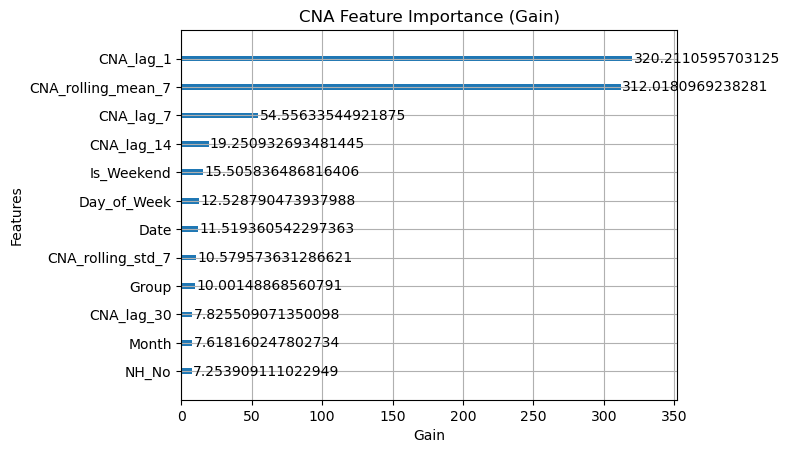

<Figure size 1000x600 with 0 Axes>

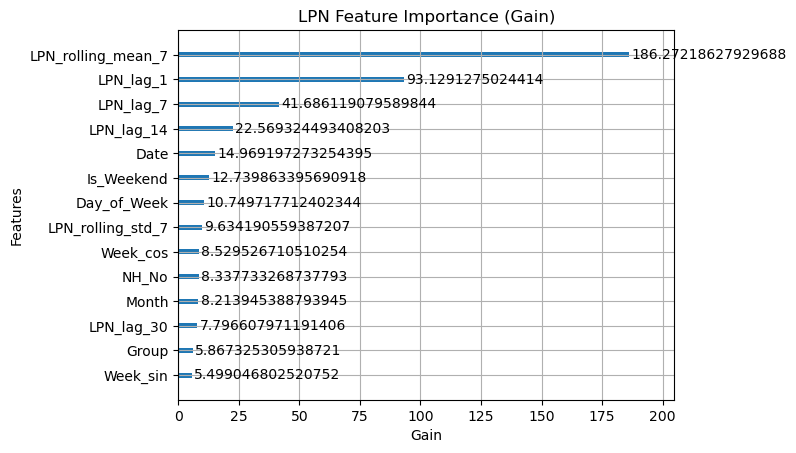

<Figure size 1000x600 with 0 Axes>

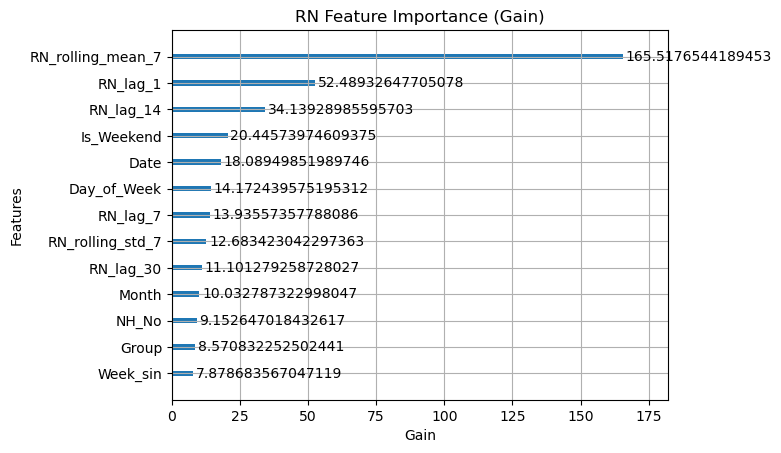

In [61]:
import matplotlib.pyplot as plt

# Plot feature importance for the CNA model (using the 0.5 quantile model)
plt.figure(figsize=(10, 6))
xgb.plot_importance(models_cna[0.5], importance_type='gain', title='CNA Feature Importance (Gain)', xlabel='Gain', max_num_features=100, ylabel='Features')
plt.show()

# Plot feature importance for the LPN model (using the 0.5 quantile model)
plt.figure(figsize=(10, 6))
xgb.plot_importance(models_lpn[0.5], importance_type='gain', title='LPN Feature Importance (Gain)', xlabel='Gain', max_num_features=100, ylabel='Features')
plt.show()

# Plot feature importance for the RN model (using the 0.5 quantile model)
plt.figure(figsize=(10, 6))
xgb.plot_importance(models_rn[0.5], importance_type='gain', title='RN Feature Importance (Gain)', xlabel='Gain', max_num_features=100, ylabel='Features')
plt.show()


In [62]:
# Fix 5: Ensure consistency between training and prediction quantiles
# If training with 0.025 and 0.975, predict with the same quantiles
quantiles = [0.025, 0.5, 0.975]

# Incorporate these fixes into your main prediction function
def get_test_predictions(models, test_df, target, expected_columns):
    """
    Generate predictions with improved confidence intervals
    """
    # Ensure test_df has the same column order as training data
    test_df = test_df[expected_columns] 

    # Get raw predictions for each quantile
    preds = get_predictions_for_target(models, test_df)
    
    # Create results dataframe
    df_pred = pd.DataFrame()
    df_pred['Date'] = test_df['Date']
    df_pred['Group'] = test_df['Group']
    df_pred[f'{target}_point'] = preds[0.5]
    df_pred[f'{target}_lower'] = preds[0.025]
    df_pred[f'{target}_upper'] = preds[0.975]
    
    # Apply domain-aware constraints
    monotonic_preds = enforce_quantile_monotonicity({
        'lower': df_pred[f'{target}_lower'],
        'point': df_pred[f'{target}_point'],
        'upper': df_pred[f'{target}_upper']
    }, caregiver_type=target)
    
    # Update dataframe with constrained predictions
    df_pred[f'{target}_lower'] = monotonic_preds['lower']
    df_pred[f'{target}_point'] = monotonic_preds['point']
    df_pred[f'{target}_upper'] = monotonic_preds['upper']
    
    return df_pred[['Date', 'Group', f'{target}_point', f'{target}_lower', f'{target}_upper']]

# Define expected columns for each caregiver type
expected_columns_cna = ['Date', 'NH_No', 'Group', 'Day_of_Week', 'Is_Weekend', 'Month', 
                        'Week_sin', 'Week_cos', 'CNA_lag_1', 'CNA_lag_7', 'CNA_lag_14', 
                        'CNA_lag_30', 'CNA_rolling_mean_7', 'CNA_rolling_std_7']

expected_columns_lpn = ['Date', 'NH_No', 'Group', 'Day_of_Week', 'Is_Weekend', 'Month', 
                        'Week_sin', 'Week_cos', 'LPN_lag_1', 'LPN_lag_7', 'LPN_lag_14', 
                        'LPN_lag_30', 'LPN_rolling_mean_7', 'LPN_rolling_std_7']

expected_columns_rn = ['Date', 'NH_No', 'Group', 'Day_of_Week', 'Is_Weekend', 'Month', 
                       'Week_sin', 'Week_cos', 'RN_lag_1', 'RN_lag_7', 'RN_lag_14', 
                       'RN_lag_30', 'RN_rolling_mean_7', 'RN_rolling_std_7']

# Generate Predictions for Each Caregiver Type
test_cna_pred = get_test_predictions(models_cna, test_cna, 'CNA', expected_columns_cna)
test_lpn_pred = get_test_predictions(models_lpn, test_lpn, 'LPN', expected_columns_lpn)
test_rn_pred  = get_test_predictions(models_rn,  test_rn,  'RN', expected_columns_rn)

In [63]:
# Map encoded date back into dataframe
test_cna_pred['Date'] = test_cna_pred['Date'].map(lambda x: pd.Timestamp.fromordinal(int(x)))
test_lpn_pred['Date'] = test_lpn_pred['Date'].map(lambda x: pd.Timestamp.fromordinal(int(x)))
test_rn_pred['Date']  = test_rn_pred['Date'].map(lambda x: pd.Timestamp.fromordinal(int(x)))

In [64]:
# Merge predictions on both "Group" and "Date" to align correctly
final_test_pred = test_cna_pred.merge(test_lpn_pred, on=['Group', 'Date']).merge(test_rn_pred, on=['Group', 'Date'])

In [65]:
final_test_pred.head()

,Date,Group,CNA_point,CNA_lower,CNA_upper,LPN_point,LPN_lower,LPN_upper,RN_point,RN_lower,RN_upper
0,2024-04-01,1,124.893845,67.159042,172.738647,65.441757,27.335498,100.303356,24.468567,7.913273,47.479633
1,2024-04-02,1,143.742325,70.034355,177.155248,71.235733,28.019355,102.127914,28.286583,8.148152,48.888908
2,2024-04-03,1,151.569962,74.990140,186.135656,73.467674,29.109012,104.121854,28.726366,8.158388,48.950326
3,2024-04-04,1,154.628555,76.380557,185.703476,73.614182,29.372121,103.045446,24.570930,8.190514,48.894953
4,2024-04-05,1,152.084824,75.354462,184.094920,73.209045,27.700453,99.323372,28.607840,8.110324,48.413812


In [66]:
def visualize_predictions(test_df, predictions_df, group_id=1):
    """
    Visualize predictions and confidence intervals for a specific group
    
    Args:
        test_df: Original test data
        predictions_df: DataFrame with predictions
        group_id: Group ID to visualize
    """
    # Filter for specific group
    group_preds = predictions_df[predictions_df['Group'] == group_id].copy()
    
    # Convert dates for plotting
    group_preds['Date'] = pd.to_datetime(group_preds['Date'])
    
    # Create figure with subplots
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Plot CNA predictions
    axes[0].plot(group_preds['Date'], group_preds['CNA_point'], 'b-', label='Point Prediction')
    axes[0].fill_between(
        group_preds['Date'], 
        group_preds['CNA_lower'], 
        group_preds['CNA_upper'], 
        alpha=0.2, 
        color='blue',
        label='95% Confidence Interval'
    )
    axes[0].set_title(f'CNA Staffing Predictions - Group {group_id}')
    axes[0].set_ylabel('Staffing Hours')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot LPN predictions
    axes[1].plot(group_preds['Date'], group_preds['LPN_point'], 'g-', label='Point Prediction')
    axes[1].fill_between(
        group_preds['Date'], 
        group_preds['LPN_lower'], 
        group_preds['LPN_upper'], 
        alpha=0.2, 
        color='green',
        label='95% Confidence Interval'
    )
    axes[1].set_title(f'LPN Staffing Predictions - Group {group_id}')
    axes[1].set_ylabel('Staffing Hours')
    axes[1].legend()
    axes[1].grid(True)
    
    # Plot RN predictions
    axes[2].plot(group_preds['Date'], group_preds['RN_point'], 'r-', label='Point Prediction')
    axes[2].fill_between(
        group_preds['Date'], 
        group_preds['RN_lower'], 
        group_preds['RN_upper'], 
        alpha=0.2, 
        color='red',
        label='95% Confidence Interval'
    )
    axes[2].set_title(f'RN Staffing Predictions - Group {group_id}')
    axes[2].set_xlabel('Date')
    axes[2].set_ylabel('Staffing Hours')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()



CI widths in test data:
CNA: Avg width: 98.13, Avg point: 155.46, Width %: 63.1%
LPN: Avg width: 50.40, Avg point: 56.12, Width %: 89.8%
RN: Avg width: 40.32, Avg point: 35.22, Width %: 114.5%


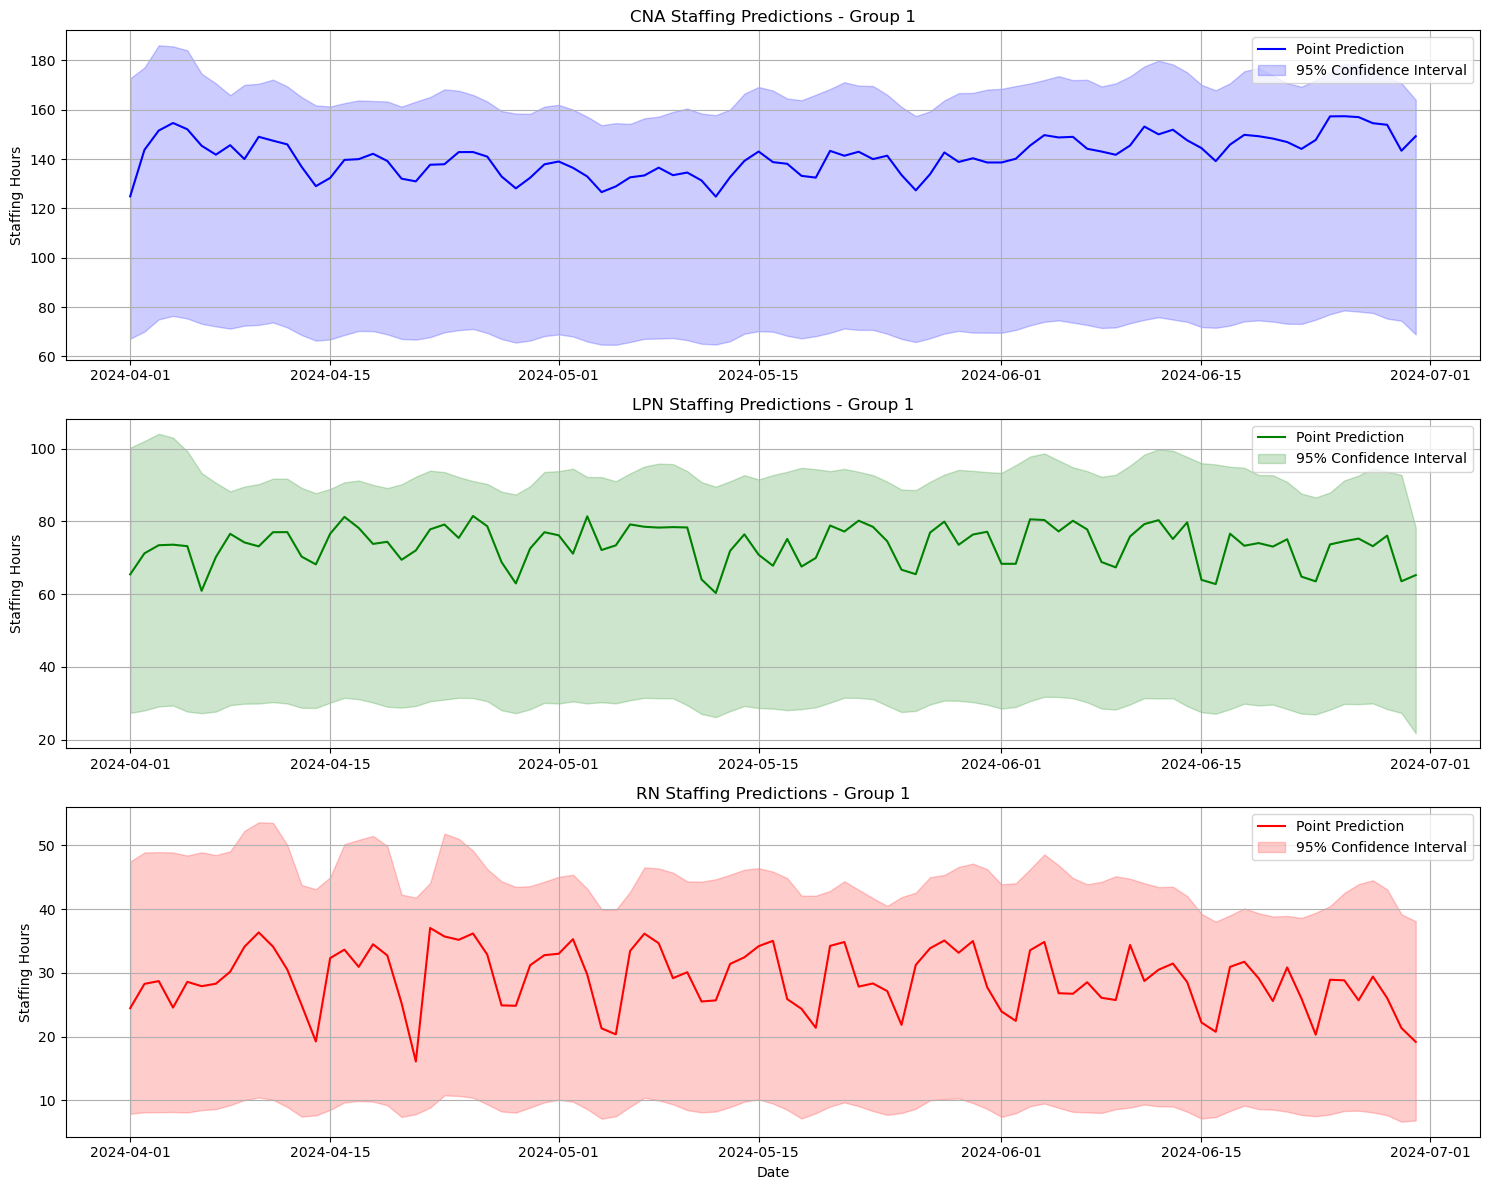

In [67]:
# Optionally: add a final validation step to check the predictions look reasonable
print("\nCI widths in test data:")
for role in ['CNA', 'LPN', 'RN']:
    avg_width = (final_test_pred[f'{role}_upper'] - final_test_pred[f'{role}_lower']).mean()
    avg_point = final_test_pred[f'{role}_point'].mean()
    print(f"{role}: Avg width: {avg_width:.2f}, Avg point: {avg_point:.2f}, Width %: {100*avg_width/avg_point:.1f}%")

# Visualize the final predictions
visualize_predictions(test_data_fe, final_test_pred, group_id=1)

In [ ]:
# # Output Excel file of predictions
# from openpyxl import Workbook
# from openpyxl.styles import Alignment, Border, Side, Font, PatternFill
# import re

# def format_predictions_to_excel(final_test_pred, output_path):
#     """
#     Format final_test_pred DataFrame into an Excel file matching the template format.
    
#     Parameters:
#     final_test_pred (pd.DataFrame): DataFrame containing prediction data
#     output_path (str): Path to save the Excel file
#     """
#     # Make a copy to avoid modifying original
#     df = final_test_pred.copy()
    
#     # Process DateGroup if it exists
#     if 'DateGroup' in df.columns:
#         # Extract group and date from DateGroup
#         # First character is assumed to be the group
#         df['Group'] = df['DateGroup'].astype(str).str[0].astype(int)
        
#         # Extract date part
#         date_pattern = r'(\d{4}-\d{2}-\d{2})'
#         df['Date'] = df['DateGroup'].astype(str).str.extract(date_pattern).pipe(pd.to_datetime)
#     else:
#         # If DateGroup doesn't exist, check for separate Date and Group columns
#         if 'Date' not in df.columns:
#             raise ValueError("DataFrame must contain 'Date' or 'DateGroup' column")
        
#         df['Date'] = pd.to_datetime(df['Date'])
        
#         if 'Group' not in df.columns:
#             df['Group'] = 1  # Default to one group
    
#     # Sort by Group and Date
#     df = df.sort_values(by=['Group', 'Date'])
    
#     # Create a new Excel workbook
#     wb = Workbook()
    
#     # Define styles
#     header_font = Font(bold=True)
#     thin_border = Border(left=Side(style='thin'), right=Side(style='thin'), 
#                          top=Side(style='thin'), bottom=Side(style='thin'))
#     center_aligned = Alignment(horizontal='center')
#     header_fill = PatternFill(start_color='E6E6E6', end_color='E6E6E6', fill_type='solid')
    
#     # Map DataFrame columns to Excel columns
#     excel_cols = {
#         'CNA_point': 'B', 'CNA_lower': 'C', 'CNA_upper': 'D',
#         'LPN_point': 'E', 'LPN_lower': 'F', 'LPN_upper': 'G',
#         'RN_point': 'H', 'RN_lower': 'I', 'RN_upper': 'J'
#     }
    
#     # Remove default sheet
#     if 'Sheet' in wb.sheetnames:
#         del wb['Sheet']
    
#     # Create a sheet for each group
#     for group in df['Group'].unique():
#         group_data = df[df['Group'] == group].copy()
#         sheet_name = f"Group {group}"
#         ws = wb.create_sheet(title=sheet_name)
        
#         # Set column widths
#         for col in range(1, 11):  # A through J
#             col_letter = chr(64 + col)  # ASCII 65 is 'A'
#             ws.column_dimensions[col_letter].width = 15
        
#         # Set up header rows
#         ws['A1'] = ""
#         ws['B1'] = "CNA"
#         ws['E1'] = "LPN"
#         ws['H1'] = "RN"
        
#         # Merge header cells
#         ws.merge_cells('B1:D1')
#         ws.merge_cells('E1:G1')
#         ws.merge_cells('H1:J1')
        
#         # Apply styles to merged header cells
#         for cell in ['B1', 'E1', 'H1']:
#             ws[cell].font = header_font
#             ws[cell].alignment = center_aligned
#             ws[cell].fill = header_fill
#             ws[cell].border = thin_border
        
#         # Set up second header row
#         headers = [
#             ('A2', 'Date'), 
#             ('B2', 'Point Prediction'), ('C2', 'Lower Bound'), ('D2', 'Upper Bound'),
#             ('E2', 'Point Prediction'), ('F2', 'Lower Bound'), ('G2', 'Upper Bound'),
#             ('H2', 'Point Prediction'), ('I2', 'Lower Bound'), ('J2', 'Upper Bound')
#         ]
        
#         for cell, value in headers:
#             ws[cell] = value
#             ws[cell].font = header_font
#             ws[cell].alignment = center_aligned
#             ws[cell].fill = header_fill
#             ws[cell].border = thin_border
        
#         # Add data rows
#         row_idx = 3
#         for _, row in group_data.iterrows():
#             # Format date to match template (MM/DD/YYYY)
#             ws[f'A{row_idx}'] = row['Date'].strftime('%m/%d/%Y')
            
#             # Add prediction values
#             for df_col, excel_col in excel_cols.items():
#                 if df_col in row and not pd.isna(row[df_col]):
#                     ws[f'{excel_col}{row_idx}'] = row[df_col]
            
#             # Apply borders to all cells in the row
#             for col in range(1, 11):  # A through J
#                 col_letter = chr(64 + col)
#                 cell = ws[f'{col_letter}{row_idx}']
#                 cell.border = thin_border
            
#             row_idx += 1
    
#     # Save the workbook
#     wb.save(output_path)
#     print(f"Excel file saved to {output_path}")

# # Example usage
# # Assuming final_test_pred is your DataFrame
# format_predictions_to_excel(final_test_pred, "example_output2.xlsx")

Excel file saved to example_output2.xlsx


## Train model for all data, no splitting


In [68]:
def train_full_models(X_full, y_full, params, quantiles, num_rounds=500):
    """
    Train models on the complete training dataset for final predictions.
    
    Parameters:
    -----------
    X_full : DataFrame
        Complete feature dataset
    y_full : Series
        Complete target dataset
    params : dict
        Model parameters
    quantiles : list
        List of quantiles to train models for
    num_rounds : int
        Number of boosting rounds
        
    Returns:
    --------
    models : dict
        Dictionary of trained models for each quantile
    """
    print(f"Training models on full dataset with {len(X_full)} observations")
    models = {}
    
    for q in quantiles:
        print(f"  Training {q} quantile model...")
        
        # Get quantile-specific parameters
        q_params = get_quantile_params(params, q)
        
        # Prepare training data
        dtrain = xgb.DMatrix(X_full, label=y_full)
        
        # Define objective and evaluation functions
        def obj(preds, dtrain):
            return quantile_loss_obj(preds, dtrain, q)
        
        def feval(preds, dtrain):
            return quantile_loss_eval(preds, dtrain, q)
        
        # Train the model
        model = xgb.train(
            q_params,
            dtrain,
            num_rounds,
            obj=obj,
            feval=feval
        )
        
        models[q] = model
        
    print("Full model training completed.")
    return models

In [69]:
# Now that we've evaluated our models, train final models on full data for production use
print("\n--- Training Full Models for Production ---")

# Prepare complete datasets with all available training data
# First, create DataFrame with all observations (without time split)
X_full_cna = pd.concat([X_train_cna, X_val_cna])
y_full_cna = pd.concat([y_train_cna, y_val_cna])

X_full_lpn = pd.concat([X_train_lpn, X_val_lpn])  
y_full_lpn = pd.concat([y_train_lpn, y_val_lpn])

X_full_rn = pd.concat([X_train_rn, X_val_rn])
y_full_rn = pd.concat([y_train_rn, y_val_rn])

# Train models on full datasets
print("\nTraining Full CNA Models...")
full_models_cna = train_full_models(X_full_cna, y_full_cna, params_cna, quantiles)

print("\nTraining Full LPN Models...")
full_models_lpn = train_full_models(X_full_lpn, y_full_lpn, params_lpn, quantiles)

print("\nTraining Full RN Models...")
full_models_rn = train_full_models(X_full_rn, y_full_rn, params_rn, quantiles)


--- Training Full Models for Production ---

Training Full CNA Models...
Training models on full dataset with 9100 observations
  Training 0.025 quantile model...
  Training 0.5 quantile model...
  Training 0.975 quantile model...
Full model training completed.

Training Full LPN Models...
Training models on full dataset with 9100 observations
  Training 0.025 quantile model...
  Training 0.5 quantile model...
  Training 0.975 quantile model...
Full model training completed.

Training Full RN Models...
Training models on full dataset with 9100 observations
  Training 0.025 quantile model...
  Training 0.5 quantile model...
  Training 0.975 quantile model...
Full model training completed.



--- Generating Final Predictions using Full Models ---

CI widths in final predictions:
CNA: Avg width: 98.04, Avg point: 156.18, Width %: 62.8%
LPN: Avg width: 50.20, Avg point: 55.82, Width %: 89.9%
RN: Avg width: 40.57, Avg point: 35.46, Width %: 114.4%

Visualizing final predictions from full models...


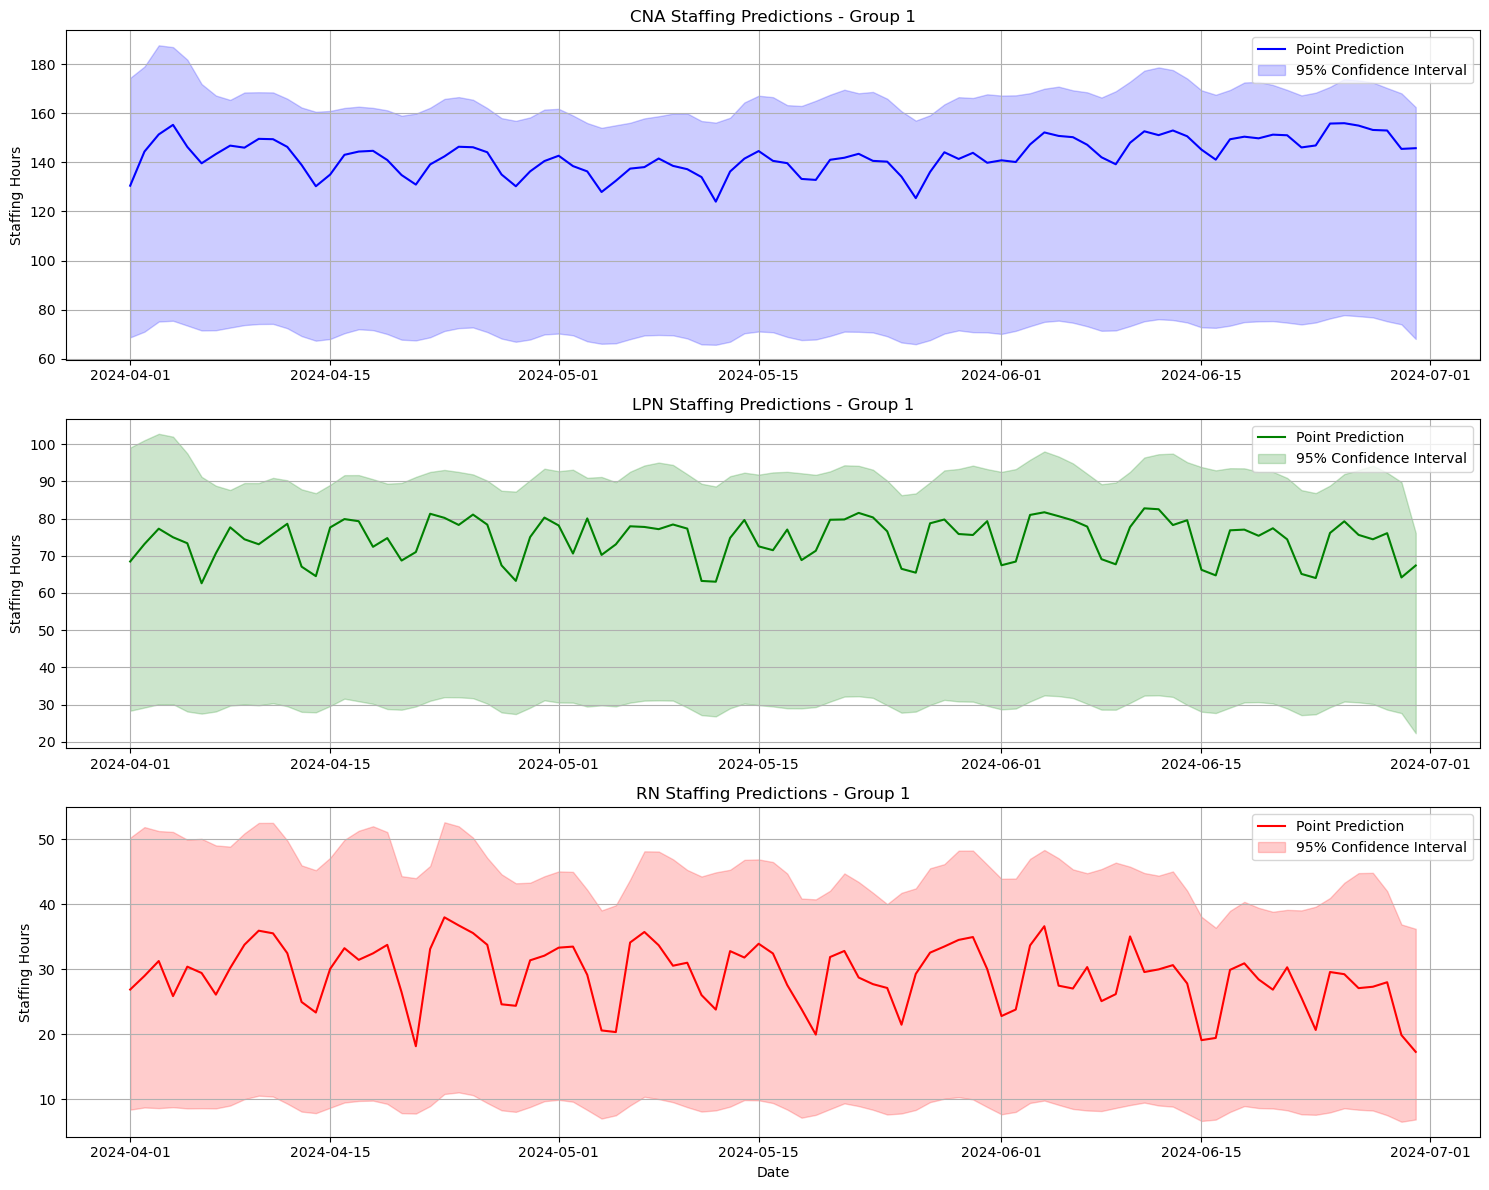

In [70]:
# Generate Predictions for Each Caregiver Type using full models
print("\n--- Generating Final Predictions using Full Models ---")
test_cna_pred = get_test_predictions(full_models_cna, test_cna, 'CNA', expected_columns_cna)
test_lpn_pred = get_test_predictions(full_models_lpn, test_lpn, 'LPN', expected_columns_lpn)
test_rn_pred = get_test_predictions(full_models_rn, test_rn, 'RN', expected_columns_rn)

# Map encoded date back into dataframe
test_cna_pred['Date'] = test_cna_pred['Date'].map(lambda x: pd.Timestamp.fromordinal(int(x)))
test_lpn_pred['Date'] = test_lpn_pred['Date'].map(lambda x: pd.Timestamp.fromordinal(int(x)))
test_rn_pred['Date'] = test_rn_pred['Date'].map(lambda x: pd.Timestamp.fromordinal(int(x)))

# Merge predictions on both "Group" and "Date" to align correctly
final_test_pred = test_cna_pred.merge(test_lpn_pred, on=['Group', 'Date']).merge(test_rn_pred, on=['Group', 'Date'])

# Optionally: add a final validation step to check the predictions look reasonable
print("\nCI widths in final predictions:")
for role in ['CNA', 'LPN', 'RN']:
    avg_width = (final_test_pred[f'{role}_upper'] - final_test_pred[f'{role}_lower']).mean()
    avg_point = final_test_pred[f'{role}_point'].mean()
    print(f"{role}: Avg width: {avg_width:.2f}, Avg point: {avg_point:.2f}, Width %: {100*avg_width/avg_point:.1f}%")

# Visualize the final predictions
print("\nVisualizing final predictions from full models...")
visualize_predictions(test_data_fe, final_test_pred, group_id=1)

In [71]:
# Output Excel file of predictions
from openpyxl import Workbook
from openpyxl.styles import Alignment, Border, Side, Font, PatternFill
import re

def format_predictions_to_excel(final_test_pred, output_path):
    """
    Format final_test_pred DataFrame into an Excel file matching the template format.
    
    Parameters:
    final_test_pred (pd.DataFrame): DataFrame containing prediction data
    output_path (str): Path to save the Excel file
    """
    # Make a copy to avoid modifying original
    df = final_test_pred.copy()
    
    # Process DateGroup if it exists
    if 'DateGroup' in df.columns:
        # Extract group and date from DateGroup
        # First character is assumed to be the group
        df['Group'] = df['DateGroup'].astype(str).str[0].astype(int)
        
        # Extract date part
        date_pattern = r'(\d{4}-\d{2}-\d{2})'
        df['Date'] = df['DateGroup'].astype(str).str.extract(date_pattern).pipe(pd.to_datetime)
    else:
        # If DateGroup doesn't exist, check for separate Date and Group columns
        if 'Date' not in df.columns:
            raise ValueError("DataFrame must contain 'Date' or 'DateGroup' column")
        
        df['Date'] = pd.to_datetime(df['Date'])
        
        if 'Group' not in df.columns:
            df['Group'] = 1  # Default to one group
    
    # Sort by Group and Date
    df = df.sort_values(by=['Group', 'Date'])
    
    # Create a new Excel workbook
    wb = Workbook()
    
    # Define styles
    header_font = Font(bold=True)
    thin_border = Border(left=Side(style='thin'), right=Side(style='thin'), 
                         top=Side(style='thin'), bottom=Side(style='thin'))
    center_aligned = Alignment(horizontal='center')
    header_fill = PatternFill(start_color='E6E6E6', end_color='E6E6E6', fill_type='solid')
    
    # Map DataFrame columns to Excel columns
    excel_cols = {
        'CNA_point': 'B', 'CNA_lower': 'C', 'CNA_upper': 'D',
        'LPN_point': 'E', 'LPN_lower': 'F', 'LPN_upper': 'G',
        'RN_point': 'H', 'RN_lower': 'I', 'RN_upper': 'J'
    }
    
    # Remove default sheet
    if 'Sheet' in wb.sheetnames:
        del wb['Sheet']
    
    # Create a sheet for each group
    for group in df['Group'].unique():
        group_data = df[df['Group'] == group].copy()
        sheet_name = f"Group {group}"
        ws = wb.create_sheet(title=sheet_name)
        
        # Set column widths
        for col in range(1, 11):  # A through J
            col_letter = chr(64 + col)  # ASCII 65 is 'A'
            ws.column_dimensions[col_letter].width = 15
        
        # Set up header rows
        ws['A1'] = ""
        ws['B1'] = "CNA"
        ws['E1'] = "LPN"
        ws['H1'] = "RN"
        
        # Merge header cells
        ws.merge_cells('B1:D1')
        ws.merge_cells('E1:G1')
        ws.merge_cells('H1:J1')
        
        # Apply styles to merged header cells
        for cell in ['B1', 'E1', 'H1']:
            ws[cell].font = header_font
            ws[cell].alignment = center_aligned
            ws[cell].fill = header_fill
            ws[cell].border = thin_border
        
        # Set up second header row
        headers = [
            ('A2', 'Date'), 
            ('B2', 'Point Prediction'), ('C2', 'Lower Bound'), ('D2', 'Upper Bound'),
            ('E2', 'Point Prediction'), ('F2', 'Lower Bound'), ('G2', 'Upper Bound'),
            ('H2', 'Point Prediction'), ('I2', 'Lower Bound'), ('J2', 'Upper Bound')
        ]
        
        for cell, value in headers:
            ws[cell] = value
            ws[cell].font = header_font
            ws[cell].alignment = center_aligned
            ws[cell].fill = header_fill
            ws[cell].border = thin_border
        
        # Add data rows
        row_idx = 3
        for _, row in group_data.iterrows():
            # Format date to match template (MM/DD/YYYY)
            ws[f'A{row_idx}'] = row['Date'].strftime('%m/%d/%Y')
            
            # Add prediction values
            for df_col, excel_col in excel_cols.items():
                if df_col in row and not pd.isna(row[df_col]):
                    ws[f'{excel_col}{row_idx}'] = row[df_col]
            
            # Apply borders to all cells in the row
            for col in range(1, 11):  # A through J
                col_letter = chr(64 + col)
                cell = ws[f'{col_letter}{row_idx}']
                cell.border = thin_border
            
            row_idx += 1
    
    # Save the workbook
    wb.save(output_path)
    print(f"Excel file saved to {output_path}")

# Example usage
# Assuming final_test_pred is your DataFrame
format_predictions_to_excel(final_test_pred, "Phase 1 Predictions Output_uncapped_high4.xlsx")

Excel file saved to Phase 1 Predictions Output_uncapped_high4.xlsx
